# Flattening an Eclipsing Binary Lightcurve Using BoxLeastSquares and Lightkurve
## Author
Aidan Niklaus

## Citations and Acknowledgements
astropy + lightkurve prolly

## Learning Outcomes


## Keywords

## Summary

## Note to Reader


## Installation
If this is your first time using Lightkurve, you will need to install it using pip. This can be done in the terminal by typing "python -m pip install lightkurve --upgrade", or within Jupyter Notebook using the "%" prefix (code block below).

In [38]:
# I have already done this, so will comment it out to reduce the length of this tutorial

# # '--upgrade' automatically installs updates
# %pip install lightkurve --upgrade

## Imports

In [10]:
import numpy as np
import lightkurve as lk
from astropy.timeseries import BoxLeastSquares
import matplotlib.pyplot as plt
%matplotlib inline

## Step -1 (lol): identify the problem probably?? Maybe go after Step 0 though...
*show non-BLS flattened LC of EB, doubles as showing off fold() while also showing why it can't work without BLS for EBs.*

## Step 0: Creating the Original Lightcurve
In order to use Astropy's BoxLeastSquares to flatten an eclipsing binary lightcurve, we must first create a lightcurve to flatten. The following code covers this, but without much explanation. If you would like to learn in depth how to create a lightcurve from scratch, please refer to [THIS]() tutorial. If you already have a lightcurve to work with, simply skip to Step 1: __________, noting that this tutorial stores it's lightcurve as the variable "lc".

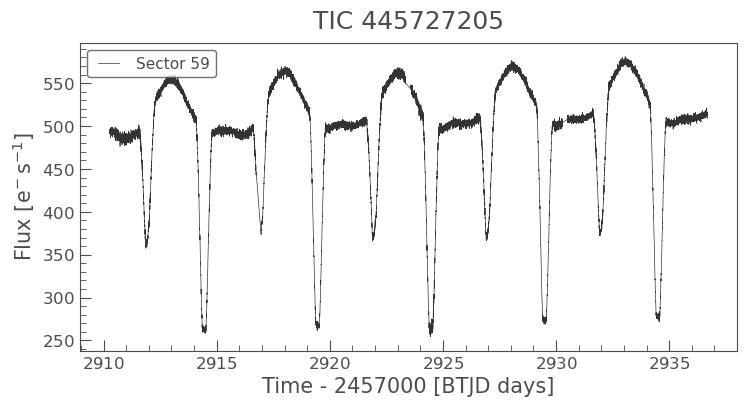

In [40]:
# Good coding practice to set our target star and sector as variables as it makes our code more modular/flexible
target = "TIC 445727205"
sector = 59

# target : the star we want to work with; the following naming formats are acceptable
    # name, e.g. "HAT-P-11"
    # identifying number, e.g. "TIC 408036613"
    # RA Dec coordinates, e.g. "285.67942179 +50.24130576" (decimal format) or "19:02:43.1 +50:14:28.7" (sexagesimal format)
    # an astropy.coordinates.SkyCoord object
search_result = lk.search_tesscut(target=target, sector=sector)

# cutout_size : specifies the TPF size ("cropped" from the FFI), in this example, we asked for a 20x20 pixel TPF
tpf = search_result[0].download(cutout_size=20)

# Creating aperture mask of our target star
target_mask = tpf.create_threshold_mask(threshold=15, reference_pixel='center')

# Creating an initial lightcurve of our target star using our target mask
initial_lc = tpf.to_lightcurve(aperture_mask=target_mask)

# Creating aperture mask of the background (to capture inherent background noise that is not taken out by quality mask)
background_mask = ~tpf.create_threshold_mask(threshold=0.001, reference_pixel=None)

# Grabbing the amount of pixels in each of our masks to ultimately use to filter out average background noise
n_target_pixels = target_mask.sum()
n_background_pixels = background_mask.sum()

# Making an average noise per pixel lightcurve
background_lc_per_pixel = (tpf.to_lightcurve(aperture_mask=background_mask) / n_background_pixels)

# Multiplying our average noise per pixel lightcurve by the amount of pixels in our target mask to find a lightcurve 
    # representing the total noise present in our star pixels
noise_lc = background_lc_per_pixel * n_target_pixels

# Subtracting the total noise lightcurve from the original lightcurve to get our corrected lightcurve
lc = initial_lc - noise_lc

# Plotting our lightcurve to see what we got!
lc.plot(title=target, label=f"Sector {sector}");

## Step 1: Setting up BoxLeastSquares (BLS)
Now that we have our eclipsing binary lightcurve (example for this tutorial pictured above), we can start the BLS process. *maybe a description of BLS/why important here...?*

Let's begin by grabbing the data BLS needs from our lightcurve.

In [41]:
# Grabbing lc data and putitng into plain arrays
time = lc.time.value
flux = lc.flux.value
# Don't technically need flux_err, but since lightkurve already gives it to us, might as well pass it along to BLS
flux_err = lc.flux_err.value

Great! Now that we have that data, we need to do two things with it. First, let's simply give it to BLS. Note: BLS is simply receiving this data, not running or computing anything yet.

In [47]:
# Giving BLS the data it needs and creating the BLS model from it (no actual computation yet)
primary_bls = BoxLeastSquares(time, flux, flux_err)

Second, let's use that data to create a period grid. Period grids are essentially a list of potential periods that BLS uses to fit itself to the periodic eclipses quintessential of eclipsing binaries. *still gotta figure out where period guess goes if anywhere, and then after that explain what's going on in the period_grid setup*

In [48]:
# Populating a list of potential period candidates --> 10,000 possible points between 0.5-20 days (can tighten if know where period should land/is)
period_grid = np.exp(np.linspace(np.log(0.5), np.log(20), 10000))

# # Best guess for orbital period (-1 if don't know)
# period_guess = -1

# # Populating a list of potential period candidates --> 10,000 possible points between 0.5-20 days (can tighten if know where period should land/is)
# if period_guess == -1:
#     period_grid = np.exp(np.linspace(np.log(0.5), np.log(20), 10000))
# else:
#     period_grid = np.exp(np.linspace(period_guess * 0.9, period_guess * 1.1, 10000))

## Step 2: Running BLS on the Primary Eclipse (maybe split into two steps: running + masking)
Now that we have given BLS everything it needs, let's run it! First BLS will identify the primary period... *prolly something here about primary vs. secondary period + what it actually means to just be fitting that primary eclipse.*

In [51]:
# Actual computation occuring. For every possible period in our period grid, BLS...
    # Phase folds the data at that period
    # Tries to fit "boxes" on the eclipse
    # Groups all its attempts into eclipse or not-eclipse categories, which it uses to define a good fit model
# duration : variety of durations (in days) BLS will test eclipses at
# oversample : higher = more accurate fits but slower, rarely need to go higher than 20
primary_result = primary_bls.power(period_grid, duration=[0.02, 0.05, 0.1, 0.2, 0.3], oversample=20)

Sweet! Now that BLS has run, there are a few things we want to grab from its result. *list + maybe explain what we're grabbing and why (need them for the mask basically)*

In [52]:
# result.power is the actual periodogram, argmax finds the index of the strongest peak (a.k.a. the index of the period)
primary_i = np.argmax(primary_result.power)
# grabbing the orbital period, reference eclipse time, and eclipse duration from the resulting model using the above index. Need this to make the transit mask for our primary eclipse
primary_period = primary_result.period[primary_i]
primary_t0 = primary_result.transit_time[primary_i]
primary_duration = primary_result.duration[primary_i]

Now we have everything we need to create a mask for the primary eclipse. *basically we need this because that way when we flatten the data we can tell lightcurve to only flatten everything outside the mask (i.e., the non-eclipse parts) and that way our eclipses stay visually in tact.*

In [53]:
# Creating the mask for the primary (bigger) eclipse (true for points inside the eclipse, false for points outside)
    # Multiplying duration by 1.5 to pad the mask on either side to be safe
primary_mask = primary_bls.transit_mask(time, primary_period, primary_duration * 1.5, primary_t0)

## Step 3: Confirming the Period with Phase Folding
BLS sometimes doesn't quite detect the correct period of our eclipsing binary, often providing a multiple or factor of the true period instead. In order to check this, we must phase fold our lightcurve. We can do this with the built-in Lightkurve function fold(). *phase folding basically folds the graph on top of itself by cutting it up in increments of whatever period you give it. If it's the true period of the star, then we will only see one cycle in our phase-folded graph. Let's try with the period BLS found when it was fitting our primary eclipse.*

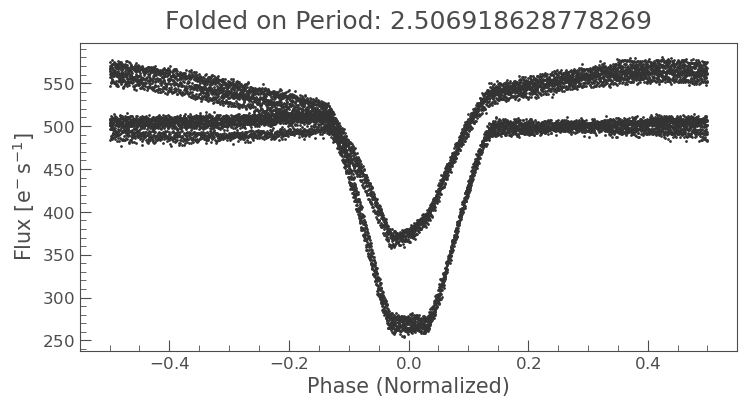

In [55]:
# period : orbital period we want to fold our graph on (increments to cut up our graph and then layer on top of each other)
# epoch_time : reference start time (may need to adjust this to help with visual confirmation)
# normalize_phase : makes time dimensionless value (helpful for visual confirmation)
folded_lc = lc.fold(period=primary_period, epoch_time=primary_t0, normalize_phase=True)
folded_lc.scatter(title=f"Folded on Period: {primary_period}");

In this instance, it looks like both our primary and secondary eclipses got folded on top of each other, meaning BLS gave us a period half of what it should be. Let's adjust that period and refold our lightcurve.

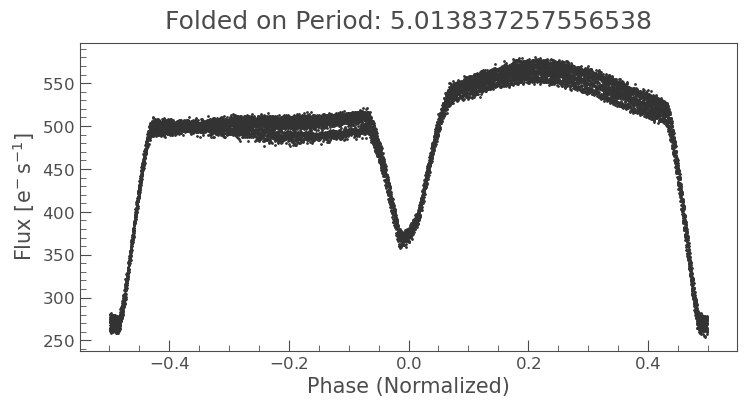

In [56]:
# Multiplying the existing period by 2 and storing it
primary_period *= 2

# Refolding lightcurve with new period
folded_lc = lc.fold(period=primary_period, epoch_time=primary_t0, normalize_phase=True)
folded_lc.scatter(title=f"Folded on Period: {primary_period}");

That looks much better, it's just shifted slightly so it makes it difficult for us to actually see if this adjusted period accurately got a full cycle. If we shift our graph over by a quarter of a cycle, we should be able to both dips clearly. We can do this by subtracting (or adding) 1/4 of a period to the reference time.

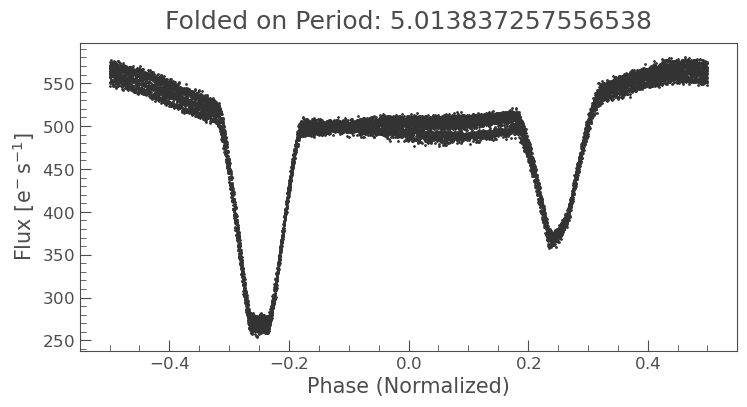

In [58]:
# Refolding lightcurve with that same new period, but now shifting it over by 1/4 of a period
folded_lc = lc.fold(period=primary_period, epoch_time=primary_t0 - (primary_period / 4), normalize_phase=True)
folded_lc.scatter(title=f"Folded on Period: {primary_period}");

Perfect! Now we can clearly see both dips within one full cycle, meaning the true period of our eclipsing binary is about 5.01 days. Awesome!

## Step 4: Running BLS on the Secondary Eclipse
Now that we have correctly identified the orbital period of our star, let's run BLS on our secondary eclipse. *but why does finding that period even matter if we aren't gonna make a period guess bc that just messes it up??*

*any mask talk?*

In [59]:
# Making another mask that is the exact opposite of the primary mask bc that way BLS doesn't even have to look at any points we already know are part of the primary eclipse
not_primary_mask = ~primary_mask

# period_guess = 5
# period_grid = np.exp(np.linspace(period_guess * 0.9, period_guess * 1.1, 10000))

# Running BLS again on all the data except the points we already know are part of the primary eclipse
secondary_bls = BoxLeastSquares(time[not_primary_mask], flux[not_primary_mask], flux_err[not_primary_mask])
secondary_result = secondary_bls.power(period_grid, duration=[0.02, 0.05, 0.1, 0.2, 0.3], oversample=20)

# Grabbing the index of the strongest peak for the secondary eclipse (a.k.a. period. Slightly redundant but good check as primary and secondary periods should be the same...)
secondary_i = np.argmax(secondary_result.power)
# Grabbing the data needed to create the transit mask for the secondary eclipse
secondary_period = secondary_result.period[secondary_i]
secondary_t0 = secondary_result.transit_time[secondary_i]
secondary_duration = secondary_result.duration[secondary_i]

# Creating the secondary eclipse mask (padded)
secondary_mask = secondary_bls.transit_mask(time, secondary_period, secondary_duration * 1.5, secondary_t0)

### checking to make sure the two periods match (don't exactly know if we need this anymore...)

In [60]:
# Printing both primary and secondary periods to console. They should match and if they do, then it adds to our confidence that we found both eclipses correctly
print("Both periods should be roughly the same as we are looking at just one star. If not, then at least one of the eclipses wasn't correctly found.")
print(f"Primary: {primary_period}")
print(f"Secondary: {secondary_period}")
print(f"If close to a whole factor, then maybe that one thing is going on... Factor: {secondary_period / primary_period}")

Both periods should be roughly the same as we are looking at just one star. If not, then at least one of the eclipses wasn't correctly found.
Primary: 5.013837257556538
Secondary: 5.010452757495982
If close to a whole factor, then maybe that one thing is going on... Factor: 0.9993249681059242


## Step 5: Combining the Masks and Flattening
Now that we have a mask for our primary and secondary eclipse, let's combine them! This will allow Lightkurve to only flatten non-eclipsing parts of our graph, in turn leaving the dipping nature of our eclipsing binary in tact throughout the process.

In [45]:
# Combining the two masks using OR logic
eclipse_mask = primary_mask | secondary_mask
# Flattening the data with the eclipsing binary mask applied!
BLS_flattened_lc = lc.flatten(mask=eclipse_mask)

### Plotting (probably include with above step)

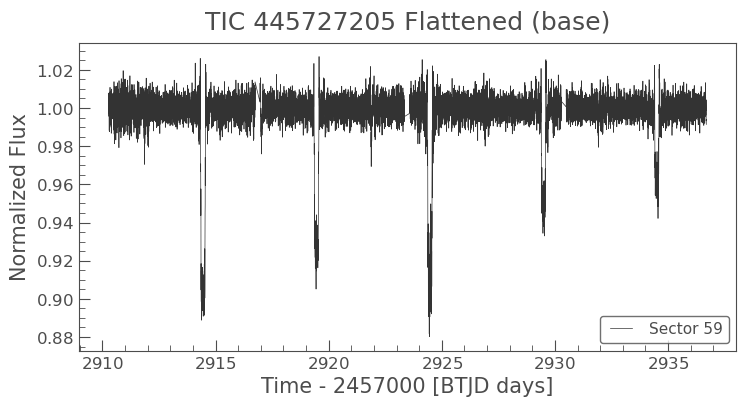

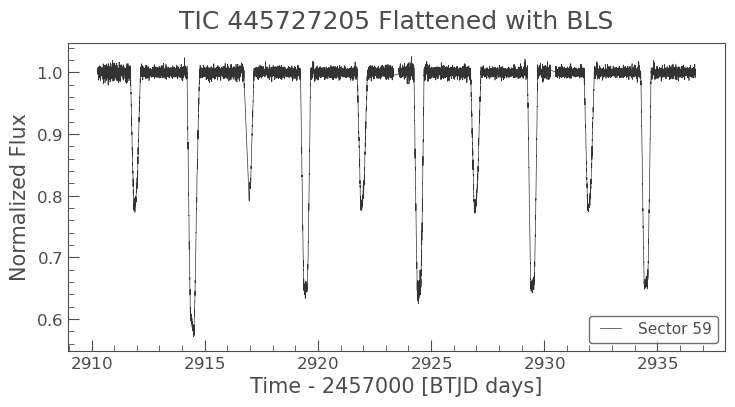

In [61]:
# =============================== PLOTTING UNFLATTENED LC vs. BASE FLATTENED LC vs. BLS FLATTENED LC =============================================================
# # Unflattened plot
# lc.plot(title=f"{target} Unflattened", label=f"Sector {sector}");

# Flattening lightcurve without BLS then plotting it
flattened_lc = lc.flatten()
flattened_lc.plot(title=f"{target} Flattened (base)", label=f"Sector {sector}");

# BLS flattened plot
BLS_flattened_lc.plot(title=f"{target} Flattened with BLS", label=f"Sector {sector}");

# ===============================================================================================================================================================